<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/PRE_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary libraries
!pip install scikit-learn opencv-python tensorflow pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf
import cv2 # OpenCV

## Basic Dataset Handling and Exploration

We'll use the famous Iris dataset to demonstrate basic data loading, inspection, and preparation.

In [3]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a Pandas DataFrame for easier handling and visualization
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]

print("First 5 rows of the dataset:")
display(iris_df.head())

print("\nDataset Information:")
iris_df.info()

print("\nDescriptive Statistics:")
display(iris_df.describe())

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data Visualization Modules

Let's visualize some aspects of the Iris dataset to understand its distribution and relationships between features.

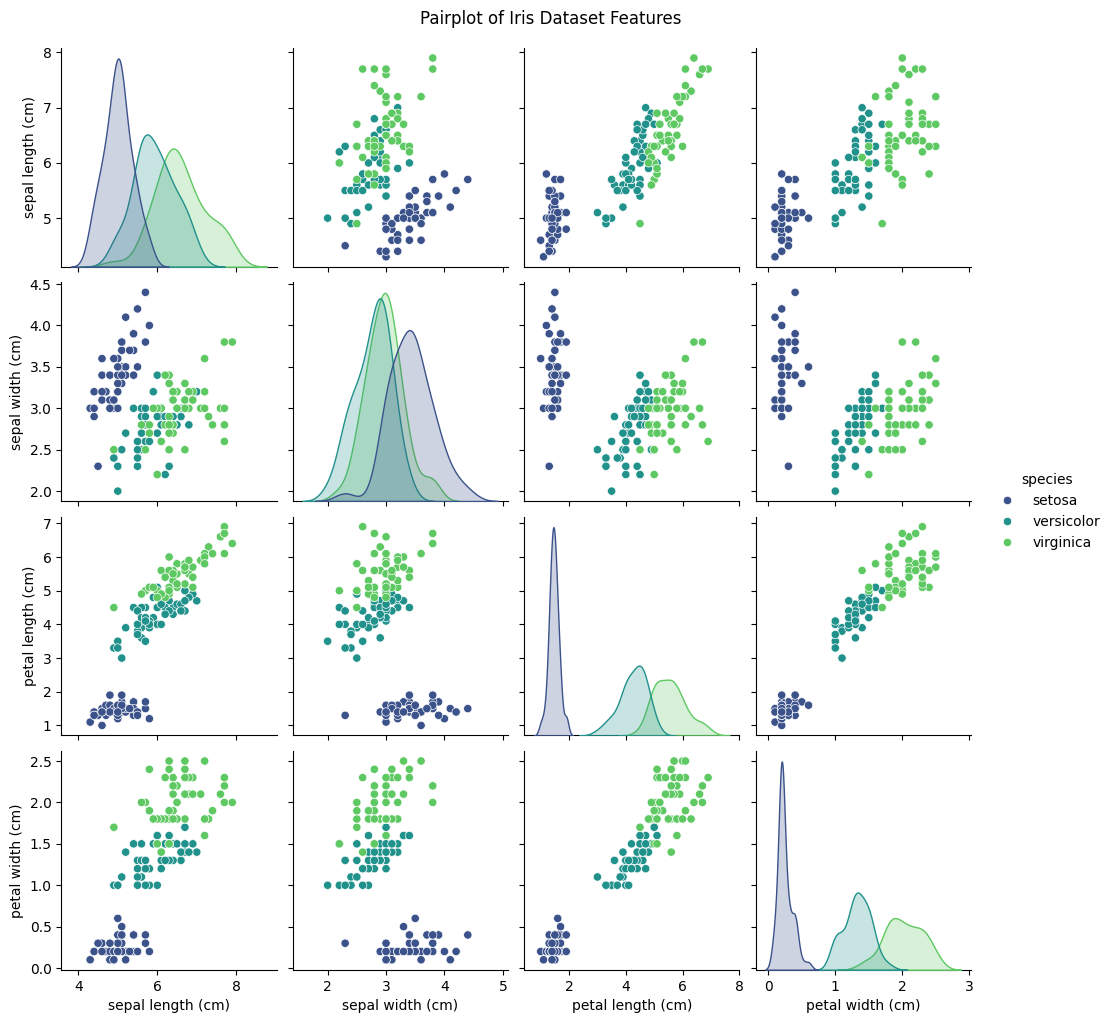

/tmp/ipykernel_1128/890747181.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=iris_df, palette='muted')
/tmp/ipykernel_1128/890747181.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=iris_df, palette='muted')
/tmp/ipykernel_1128/890747181.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=iris_df, palette='muted')
/tmp/ipykernel_1128/890747181.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

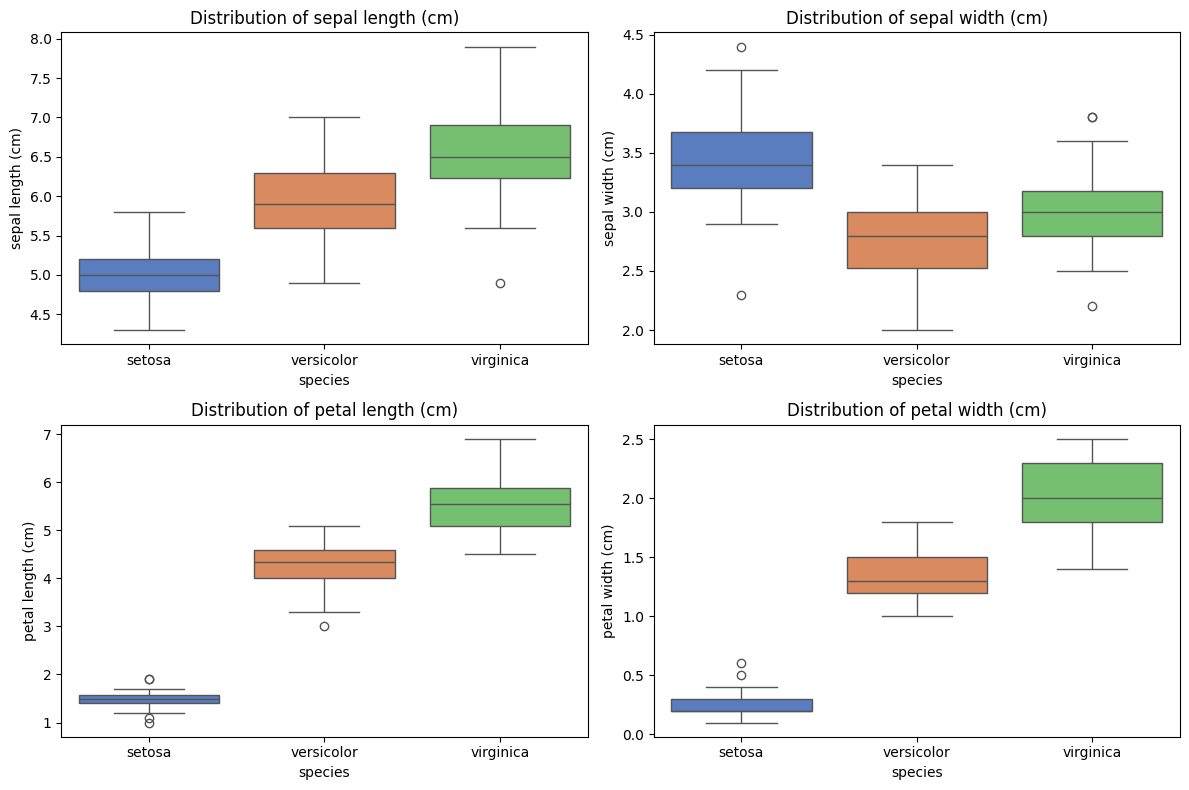

In [4]:
# Pairplot to visualize relationships between all features
sns.pairplot(iris_df, hue='species', palette='viridis')
plt.suptitle('Pairplot of Iris Dataset Features', y=1.02)
plt.show()

# Boxplot for individual feature distributions per species
plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=iris_df, palette='muted')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## Basic Scikit-Learn Demonstration (K-Nearest Neighbors)

Here's a quick demonstration of a simple classification model using Scikit-learn.

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (important for many ML algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# Make predictions and evaluate the model
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"K-Nearest Neighbors Classifier Accuracy: {accuracy:.2f}")

K-Nearest Neighbors Classifier Accuracy: 1.00


## Basic TensorFlow Demonstration

This shows how to create a simple neural network with TensorFlow.

In [6]:
# Build a simple Sequential model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax') # 3 classes for Iris
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nTensorFlow Model Test Accuracy: {accuracy:.2f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.3214 - loss: 1.2885 - val_accuracy: 0.4762 - val_loss: 1.0821
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 1.2640 - val_accuracy: 0.4762 - val_loss: 1.0662
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 1.2392 - val_accuracy: 0.4762 - val_loss: 1.0506
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 1.2165 - val_accuracy: 0.4762 - val_loss: 1.0356
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3214 - loss: 1.1935 - val_accuracy: 0.4762 - val_loss: 1.0219
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 1.1703 - val_accuracy: 0.4762 - val_loss: 1.0085
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 1.1501 - val_accuracy: 0.4762 - val_loss: 0.9954
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3214 - loss: 1.1304 - val_accuracy: 0.4762 - val_loss: 0.9826

## Basic OpenCV Demonstration

OpenCV is primarily for image and video processing. Here's a very simple example of creating and displaying a blank image.

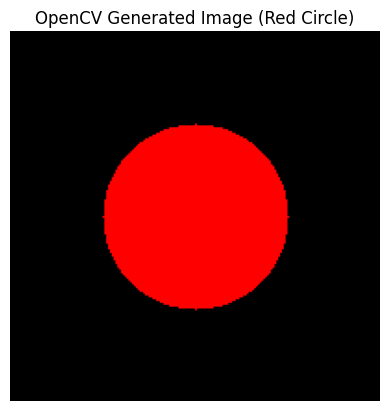

In [7]:
# Create a black image (200x200 pixels)
blank_image = np.zeros((200, 200, 3), dtype=np.uint8) # Black image

# Draw a red circle in the center
center = (100, 100)
radius = 50
color = (0, 0, 255) # Red in BGR format
thickness = -1 # Filled circle
cv2.circle(blank_image, center, radius, color, thickness)

# Display the image using matplotlib (OpenCV usually requires `imshow` or `imwrite`)
plt.imshow(cv2.cvtColor(blank_image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title('OpenCV Generated Image (Red Circle)')
plt.axis('off')
plt.show()